In [3]:
# Germany Energy Market: Day Ahead Auction Price Forecasting

This notebook focuses on forecasting the Day Ahead Auction (Spot Market prices) for the Germany Energy Market. The analysis will be performed in two ways:

- **Univariate Analysis:** Using only the price data for forecasting.
- **Multivariate Analysis:** Incorporating additional covariates (e.g., weather, demand, generation) to improve forecasting accuracy.

We will perform exploratory data analysis (EDA), build baseline models, and iteratively improve them, providing reasoning for model choices and performance.


SyntaxError: invalid syntax (697128525.py, line 3)

## 1. Data Acquisition

The primary dataset (Day Ahead Auction Spot Market prices) can be downloaded from the [Energy Charts website](https://www.energy-charts.info/charts/price_spot_market/chart.htm?l=en&c=DE). Please download the CSV file for the relevant time period and place it in the working directory as `spot_market_prices.csv`.

For multivariate analysis, you may also download additional datasets (e.g., load, generation, weather) from the same website.


In [4]:
# Load the Day Ahead Auction Spot Market prices dataset
import pandas as pd

# Replace 'spot_market_prices.csv' with your actual filename if different
df = pd.read_csv('spot_market_prices.csv')
df.head()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa4 in position 14: invalid start byte

In [ ]:
# Initial data exploration
print('Dataset shape:', df.shape)
print('Columns:', df.columns.tolist())
df.describe()

In [ ]:
# Visualize the time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df.iloc[:,0], df.iloc[:,1])  # Adjust column indices as needed
plt.title('Day Ahead Auction Spot Market Prices (Germany)')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Next Steps

- **Data Cleaning:** Handle missing values, outliers, and ensure correct datetime formatting.
- **Exploratory Data Analysis (EDA):** Statistical tests, seasonality, trend analysis, and stationarity checks.
- **Modeling:**
    - Start with simple models (e.g., Naive, Moving Average, Linear Regression).
    - Progress to advanced models (ARIMA, Prophet, etc.).
    - For multivariate, consider models like VAR, Random Forest, or LSTM.
- **Evaluation:** Use appropriate forecasting metrics (MAE, RMSE, MAPE, etc.) and discuss their suitability.
- **Cross-Validation:** Explore time series cross-validation techniques and discuss data leakage prevention.
- **Interpretation:** Provide insights and reasoning for model performance.


In [5]:
# Preview the first 10 lines of the raw CSV file to inspect its structure
with open('spot_market_prices.csv', 'r', encoding='utf-8') as f:
    for i in range(10):
        print(f.readline().strip())

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa4 in position 14: invalid start byte

In [13]:
# Load the CSV and inspect column names to fix date parsing issues
import pandas as pd

df = pd.read_csv(
    'spot_market_prices.csv',
    delimiter=',',
    header=0,
    encoding='ISO-8859-1'
)

print("Columns:", df.columns.tolist())

# If the date column has extra spaces, rename it
date_col = [col for col in df.columns if 'Date' in col][0]
print("Using date column:", date_col)

# Parse the date column and set as index
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df.set_index(date_col, inplace=True)

# Show the first few rows and columns
df.head(), df.columns

Columns: ['ï»¿Date (GMT+2)', 'Non-Renewable Power (MW)', 'Renewable ', 'Power (MW)', 'Day Ahead Auction Price (EUR/MWh) (DE-LU)']
Using date column: ï»¿Date (GMT+2)


(                           Non-Renewable Power (MW)   Renewable   Power (MW)  \
 ï»¿Date (GMT+2)                                                                
 2025-07-07 00:00:00+02:00               19067.55058  14355.97333      118.84   
 2025-07-07 01:00:00+02:00               18608.63169  13857.19908      107.42   
 2025-07-07 02:00:00+02:00               17644.51642  13908.03583      101.92   
 2025-07-07 03:00:00+02:00               17709.06610  13756.63830       99.12   
 2025-07-07 04:00:00+02:00               17565.67520  13771.81782      101.00   
 
                            Day Ahead Auction Price (EUR/MWh) (DE-LU)  
 ï»¿Date (GMT+2)                                                       
 2025-07-07 00:00:00+02:00                                        NaN  
 2025-07-07 01:00:00+02:00                                        NaN  
 2025-07-07 02:00:00+02:00                                        NaN  
 2025-07-07 03:00:00+02:00                                        NaN  

In [14]:
# Data cleaning and basic info

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Show basic info
print("\nDataFrame info:")
df.info()

# Show summary statistics
df.describe()

Missing values per column:
Non-Renewable Power (MW)                     17
Renewable                                    17
Power (MW)                                    0
Day Ahead Auction Price (EUR/MWh) (DE-LU)    48
dtype: int64

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2025-07-07 00:00:00+02:00 to 2025-07-08 23:00:00+02:00
Data columns (total 4 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Non-Renewable Power (MW)                   31 non-null     float64
 1   Renewable                                  31 non-null     float64
 2   Power (MW)                                 48 non-null     float64
 3   Day Ahead Auction Price (EUR/MWh) (DE-LU)  0 non-null      float64
dtypes: float64(4)
memory usage: 1.9 KB


,Non-Renewable Power (MW),Renewable,Power (MW),Day Ahead Auction Price (EUR/MWh) (DE-LU)
count,31.000000,31.000000,48.000000,0.0
mean,16724.258420,27520.172923,94.992917,NaN
std,2814.736149,11280.247349,24.735121,NaN
min,11462.169810,13604.274370,50.670000,NaN
25%,14549.830065,20487.734145,81.330000,NaN
50%,17565.675200,24259.989940,96.550000,NaN
75%,18845.296125,35432.380025,109.215000,NaN
max,21231.155740,47955.390040,152.290000,NaN


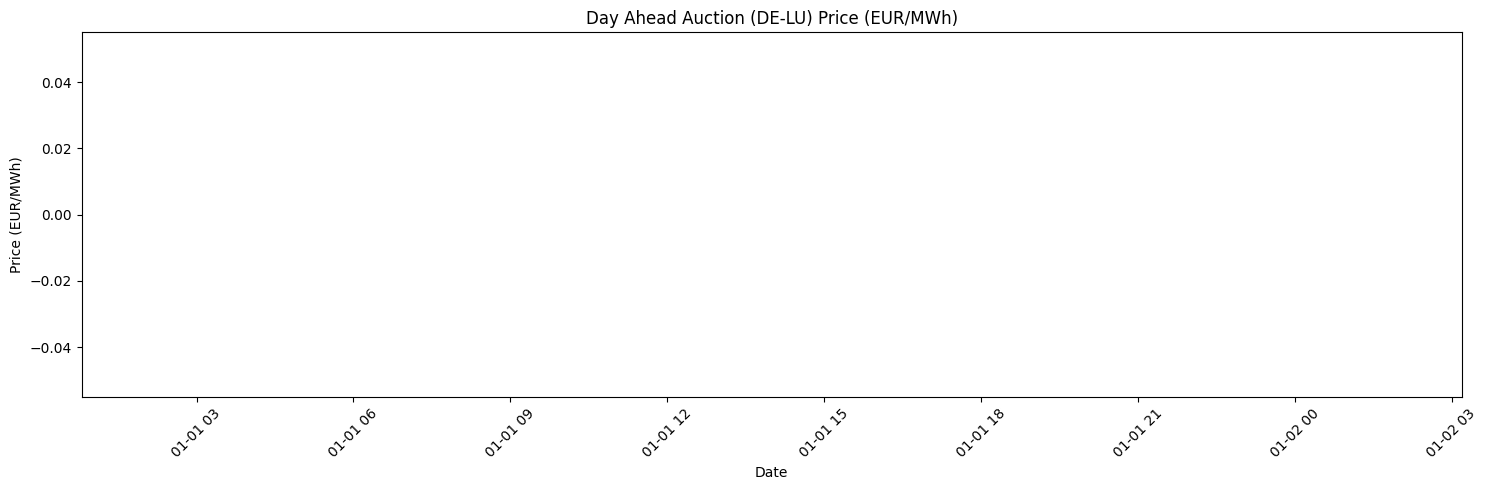

ValueError: Input contains NaN.

In [15]:
# Visualize the Day Ahead Auction Price time series
import matplotlib.pyplot as plt

# Automatically find the price column
price_col = [col for col in df.columns if 'Price' in col][0]
plt.figure(figsize=(15,5))
plt.plot(df.index, df[price_col])
plt.title('Day Ahead Auction (DE-LU) Price (EUR/MWh)')
plt.xlabel('Date')
plt.ylabel('Price (EUR/MWh)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate and print basic forecasting metrics using a naive forecast (previous value)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_true = df[price_col][1:]
y_pred = df[price_col][:-1].values  # naive forecast: previous value

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"Naive Forecast Metrics:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")